In [1]:
from regime_detector import RegimeDetector
import matplotlib.pyplot as plt

from IPython.display import display

In [2]:
def plot_regime_timeline(
    detector: RegimeDetector,
    *,
    start_date: str,
    end_date: str,
    shift: bool = True,
):
    """
    Plots regime states over time as colored background regions.
    """

    df = detector.build_regimes(start_date=start_date, end_date=end_date)

    if shift and detector.shift_regime_by_one_day:
        df["RegimeLabel"] = df["RegimeLabel"].shift(1)

    df = df.dropna(subset=["RegimeLabel"]).copy()

    # Map regime to color
    regime_colors = {
        "Stable Risk-On": "#2ca02c",   # green
        "Fragile": "#ffbf00",          # amber
        "Vol Shock": "#ff7f0e",        # orange
        "Crisis": "#d62728",           # red
    }

    fig, ax = plt.subplots(figsize=(14, 5))

    current_regime = None
    start_idx = None

    for i, (date, row) in enumerate(df.iterrows()):
        regime = row["RegimeLabel"]

        if regime != current_regime:
            # close previous region
            if current_regime is not None:
                ax.axvspan(start_idx, prev_date,
                           color=regime_colors[current_regime],
                           alpha=0.35)
            # start new region
            current_regime = regime
            start_idx = date

        prev_date = date

    # close final region
    if current_regime is not None:
        ax.axvspan(start_idx, prev_date,
                   color=regime_colors[current_regime],
                   alpha=0.35)

    ax.set_title("Market Regime Timeline (EMA Smoothed)", fontsize=14)
    ax.set_ylabel("Regime State")
    ax.set_yticks([])

    # Legend
    handles = [
        plt.Line2D([0], [0], color=color, lw=6, alpha=0.5)
        for color in regime_colors.values()
    ]
    ax.legend(handles, regime_colors.keys(), loc="upper left")

    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd
from IPython.display import display

def display_regime_diagnostics(result: dict):
    """
    Pretty Jupyter display for detector.dominant_regime(return_diagnostics=True)
    Compatible with pandas 2.x
    """

    regime_color = {
        "stale_risk_on": "#2ca02c",
        "fragile": "#ffbf00",
        "vol_shock": "#ff7f0e",
        "crisis": "#d62728",
    }

    # ----------------------------
    # 1️⃣ Summary Section
    # ----------------------------
    summary = pd.DataFrame({
        "Field": [
            "As Of",
            "Last Data Date",
            "Dominant Regime",
            "Last Daily Regime",
            "Dominance Window",
            "EMA Span",
        ],
        "Value": [
            result.get("as_of"),
            result.get("last_date_in_data"),
            result.get("dominant_regime"),
            result.get("last_regime"),
            result.get("dominance_window"),
            result.get("ema_span"),
        ]
    })

    def color_regime(val):
        if val in regime_color:
            return f"color: white; background-color: {regime_color[val]}; font-weight: bold;"
        return ""

    styled_summary = (
        summary.style
        .map(color_regime, subset=["Value"])
        .set_properties(**{"font-size": "13px"})
        .hide(axis="index")
    )

    display(styled_summary)

    # ----------------------------
    # 2️⃣ Regime Counts
    # ----------------------------
    counts_df = pd.DataFrame(
        list(result.get("counts", {}).items()),
        columns=["Regime Label", "Count"]
    ).sort_values("Count", ascending=False)

    styled_counts = (
        counts_df.style
        .background_gradient(cmap="Blues", subset=["Count"])
        .set_properties(**{"font-size": "13px"})
        .hide(axis="index")
        .set_caption("Dominance Window Distribution")
    )

    display(styled_counts)

    # ----------------------------
    # 3️⃣ Parameters
    # ----------------------------
    params_df = pd.DataFrame(
        list(result.get("params", {}).items()),
        columns=["Parameter", "Value"]
    )

    styled_params = (
        params_df.style
        .set_properties(**{"font-size": "12px"})
        .hide(axis="index")
        .set_caption("Detector Parameters")
    )

    display(styled_params)

In [4]:
detector = RegimeDetector(
    ema_span=60,          # try 7, 14, 20, etc.
    lookback=252,
    credit_mode="ratio",
    shift_regime_by_one_day=True,
)

In [5]:
result = detector.dominant_regime(return_diagnostics=True)
display_regime_diagnostics(result)

Field,Value
As Of,2026-02-27
Last Data Date,2026-02-27
Dominant Regime,stable_risk_on
Last Daily Regime,stable_risk_on
Dominance Window,20
EMA Span,60


Regime Label,Count
Stable Risk-On,20


Parameter,Value
vix_high_pct,0.700000
spread_wide_pct,0.700000
lookback,252
credit_mode,ratio
shift_regime_by_one_day,True
tickers,"['^VIX', 'HYG', 'LQD']"


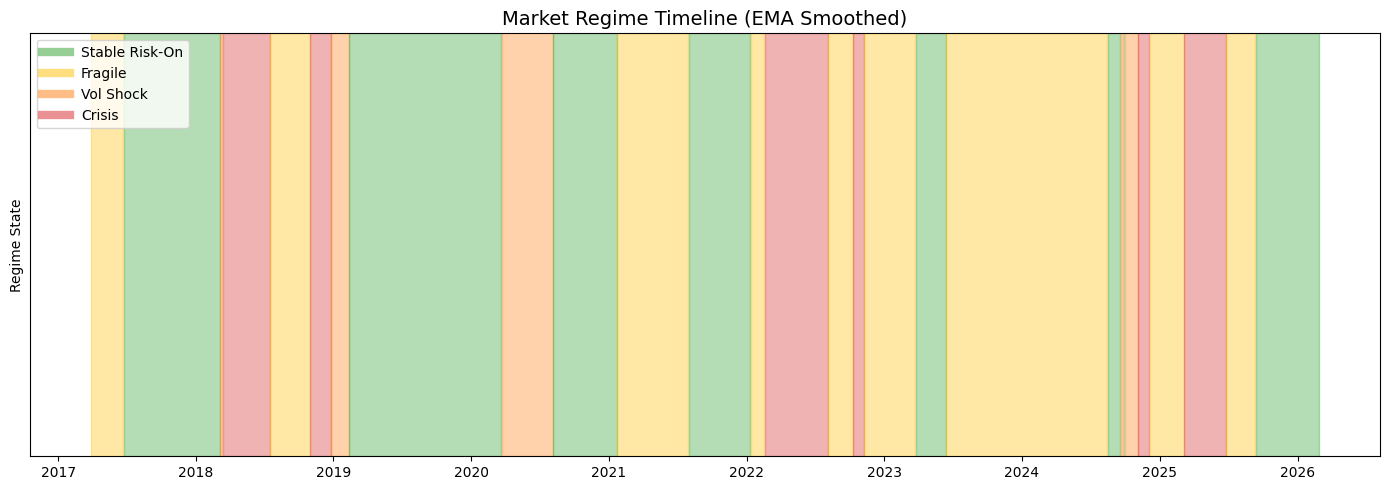

In [6]:
plot_regime_timeline(
    detector,
    start_date="2016-01-01",
    end_date=str(pd.Timestamp.today().date()),
)